# Online2 Solver Logs Analysis

Questo notebook visualizza i log prodotti dal scheduler (`online2`) a ogni esecuzione del solver.

Contiene:
- andamento del tempo medio di processing per richiesta e per batch
- un grafico stacked per ciascuna esecuzione del solver con assegnamenti, errori medi per slot e capacity levels

In [37]:
%matplotlib inline
import pathlib
import sys

cwd = pathlib.Path.cwd().resolve()
candidates = [cwd, cwd.parent]
for candidate in candidates:
    if (candidate / 'config.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

import matplotlib.pyplot as plt
import pandas as pd

import config
import importlib
import visualize_solver_logs as viz
importlib.reload(viz)
from visualize_solver_logs import (
    load_solver_logs,
    load_infeasibility_debug_logs,
    plot_processing_times,
    plot_carbon_cost_trend,
    plot_carbon_intensity_by_slot,
    plot_error_window_trend,
    plot_solver_execution_stacked,
    plot_infeasibility_overview,
    plot_infeasibility_event,
    select_run_ids,
)


In [38]:
# Run selection options for stacked assignment plots
# all | first_per_slot | last_per_slot | all_for_slot
RUN_SELECTION_MODE = "first_per_slot"
TARGET_SLOT = None  # used only when RUN_SELECTION_MODE == "all_for_slot"

# Strict-infeasible debug event selection
# None => latest event
INFEASIBILITY_EVENT_ID = None

runs_df, assignments_df, slot_metrics_df = load_solver_logs(
    runs_file=config.SOLVER_RUNS_FILE,
    assignments_file=config.SOLVER_ASSIGNMENTS_FILE,
    slot_metrics_file=config.SOLVER_SLOT_METRICS_FILE,
    only_runs_with_assignments=True,
)
debug_df = load_infeasibility_debug_logs(config.SOLVER_INFEASIBLE_DEBUG_FILE)

selected_run_ids = select_run_ids(
    runs_df,
    mode=RUN_SELECTION_MODE,
    target_slot=TARGET_SLOT,
) if not runs_df.empty else []

print(f"runs: {len(runs_df)}")
print(f"assignments rows: {len(assignments_df)}")
print(f"slot metrics rows: {len(slot_metrics_df)}")
print(f"strict-infeasible debug events: {len(debug_df)}")
print(f"selected stacked plots: {len(selected_run_ids)}")

display(runs_df.head())
if not debug_df.empty:
    display(debug_df.tail(5))


runs: 81
assignments rows: 9963
slot metrics rows: 1944
strict-infeasible debug events: 2
selected stacked plots: 12


,run_id,run_sequence,current_slot,pending_batch_size,total_assignments,new_assignments,replanned_assignments,solver_status,solver_mode,lock_future_assignments,...,carbon_cost_per_assignment,error_window_avg_after,error_window_avg_after_real,error_window_start_slot,error_window_end_slot,error_window_threshold,error_window_violated_after,error_window_violated_after_real,batches_processed_after,total_scheduled_after
0,1777470087442-1,1,1,3,3,3,0,ok,dp,True,...,11100.0,3.068966,5.0,0,9,4.0,False,True,1,3
1,1777470087573-1,2,1,3,3,3,0,ok,dp,True,...,9500.0,3.133333,5.0,0,9,4.0,False,True,2,6
2,1777470087684-1,3,1,3,3,3,0,ok,dp,True,...,8700.0,3.193548,5.0,0,9,4.0,False,True,3,9
3,1777470087793-1,4,1,3,3,3,0,ok,dp,True,...,8700.0,3.250000,5.0,0,9,4.0,False,True,4,12
4,1777470087904-1,5,1,3,3,3,0,ok,dp,True,...,12700.0,3.303030,5.0,0,9,4.0,False,True,5,15


,event_id,timestamp,current_slot,pending_batch_size,pending_request_details,strict_threshold,baseline_error_sum,baseline_request_count,baseline_average_error,min_strategy_error,...,max_possible_avg_error_pending_only,strict_infeasible_by_error_bound,strict_scheduled_pending_count,relaxed_scheduled_pending_count,relaxed_success,lock_future_assignments,future_assignment_count,future_slot_counts,future_assignment_details,all_active_slot_counts
0,1777470127345-5,1.777470e+09,5,3,87:6|88:8|89:13,4.0,444.5,107,4.154206,1.0,...,4.177273,True,0,3,True,True,38,5:9|8:10|9:10|10:9,40:5:7:Fast|56:5:7:Balanced|57:5:5:Fast|60:5:5...,1:2|2:13|3:14|4:20|5:9|8:10|9:10|10:9
1,1777470127460-5,1.777470e+09,5,3,92:6|91:10|90:12,4.0,447.5,110,4.068182,1.0,...,4.092920,False,0,3,True,True,41,5:10|7:1|8:10|9:10|10:10,40:5:7:Fast|56:5:7:Balanced|57:5:5:Fast|60:5:5...,1:2|2:13|3:14|4:20|5:10|7:1|8:10|9:10|10:10


## 1) Performance, costi carbon e trend errore window

Grafici riassuntivi:
- tempo medio per richiesta e tempo totale per batch
- costo carbon totale per run e costo carbon per richiesta
- carbon intensity per slot
- andamento di `error_window_avg_after` (modeled) e `error_window_avg_after_real`


,run_id,current_slot,solver_mode,total_carbon_cost,carbon_cost_per_new_request,new_assignments,error_window_avg_after,error_window_avg_after_real,error_window_threshold
0,1777470087442-1,1,dp,33300.0,11100.000000,3,3.068966,5.0,4.0
1,1777470087573-1,1,dp,28500.0,9500.000000,3,3.133333,5.0,4.0
2,1777470087684-1,1,dp,26100.0,8700.000000,3,3.193548,5.0,4.0
3,1777470087793-1,1,dp,26100.0,8700.000000,3,3.250000,5.0,4.0
4,1777470087904-1,1,dp,38100.0,12700.000000,3,3.303030,5.0,4.0
5,1777470097379-2,2,dp,33300.0,11100.000000,3,3.363636,5.0,4.0
6,1777470097492-2,2,dp,33300.0,11100.000000,3,3.411765,5.0,4.0
7,1777470097598-2,2,dp,33300.0,11100.000000,3,3.457143,5.0,4.0
8,1777470097703-2,2,dp,77700.0,25900.000000,3,3.500000,5.0,4.0
9,1777470097808-2,2,dp,37000.0,12333.333333,3,3.540541,5.0,4.0


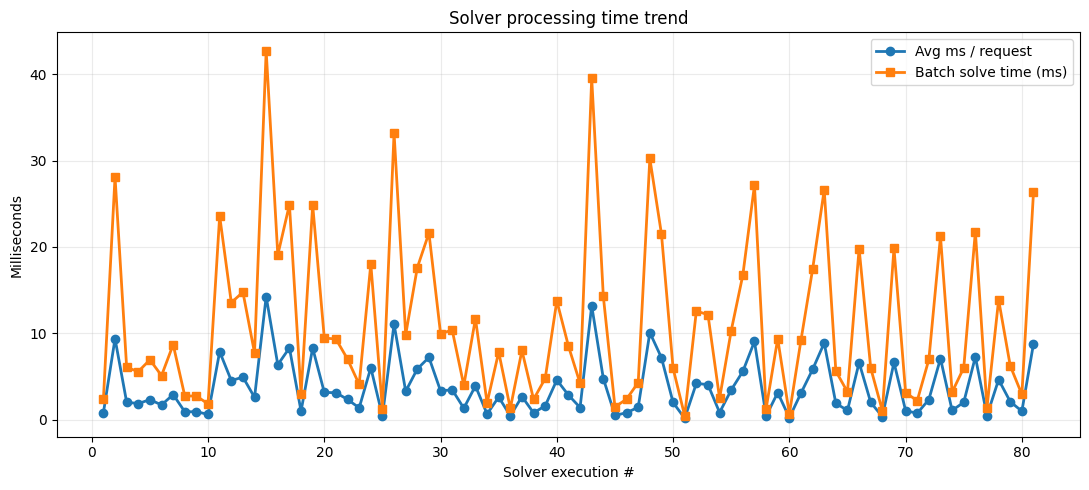

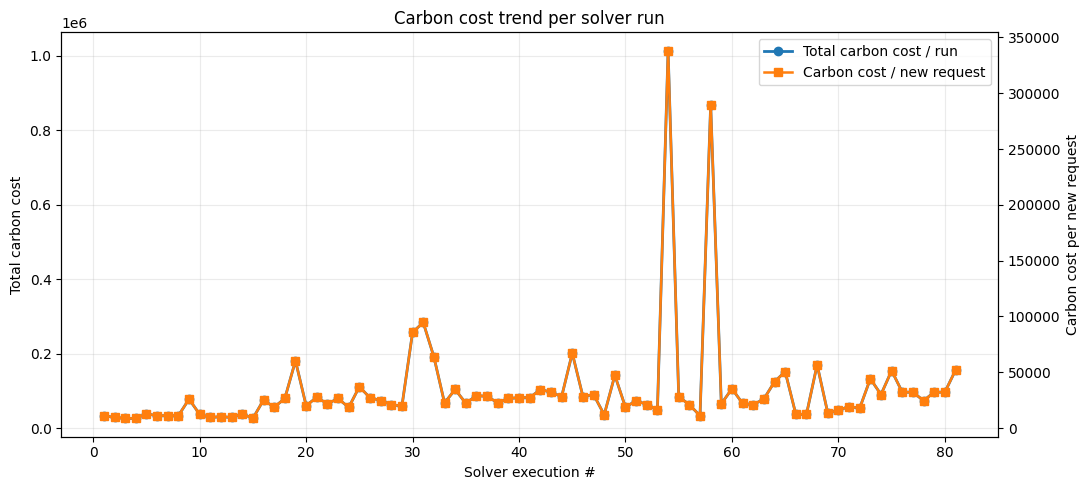

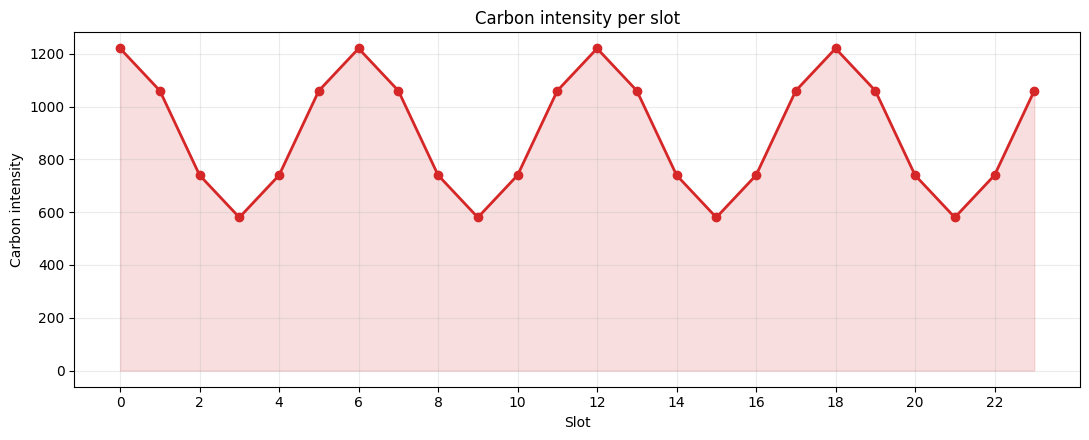

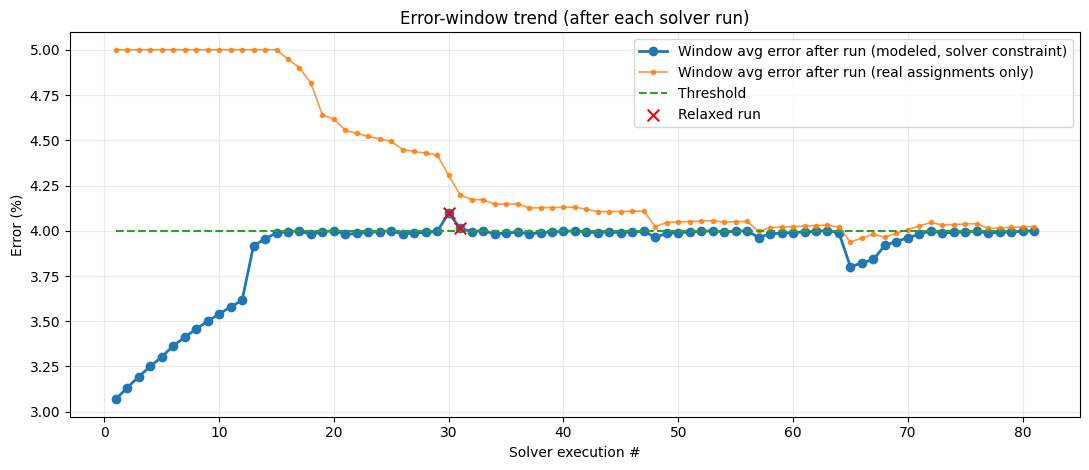

In [39]:
if runs_df.empty:
    print("Nessun dato disponibile in SOLVER_RUNS_FILE")
else:
    display_cols = [
        c for c in [
            'run_id',
            'current_slot',
            'solver_mode',
            'total_carbon_cost',
            'carbon_cost_per_new_request',
            'new_assignments',
            'error_window_avg_after',
            'error_window_avg_after_real',
            'error_window_threshold',
        ] if c in runs_df.columns
    ]
    display(runs_df.sort_values('solver_start_ts')[display_cols].head(10))

    fig = plot_processing_times(runs_df)
    plt.show()

    if 'total_carbon_cost' in runs_df.columns:
        fig = plot_carbon_cost_trend(runs_df)
        plt.show()

fig = plot_carbon_intensity_by_slot(slot_metrics_df)
plt.show()

if runs_df.empty:
    print("Nessun dato disponibile per il trend errore window")
else:
    fig = plot_error_window_trend(runs_df)
    plt.show()


## 2) Assegnamenti per esecuzione solver (stacked bars)

Ogni grafico mostra **tutte** le richieste attive in quel run (non solo le N nuove).
Le richieste nuove del run sono evidenziate, quelle preesistenti sono più trasparenti.

Su ogni grafico stacked trovi:
- errore medio per singolo slot
- segmento dell'errore medio della window `[start,end]` (modeled e real)
- threshold errore

Per mostrare un solo run per slot usa `RUN_SELECTION_MODE="first_per_slot"` (o `"last_per_slot"`).


## Legenda rapida dei grafici

- **Window avg (modeled)**: media errore nella finestra usata dal solver per il vincolo strict. Include eventuali contributi sintetici (es. pre-history/mock recovery).
- **Window avg (real)**: media errore calcolata solo sulle richieste realmente assegnate nel sistema (nessun contributo sintetico).
- **Avg error per slot**: media errore delle richieste assegnate in quel singolo slot (non è una media di finestra).
- **Window avg by timeslot (0..current, modeled)**: per ogni time slot `t` da 0 a `current`, mostra la media errore di finestra nella versione modeled (allineata al vincolo solver).

Nei rettangoli stacked: `request_id/deadline_slot` (es. `43/2`).


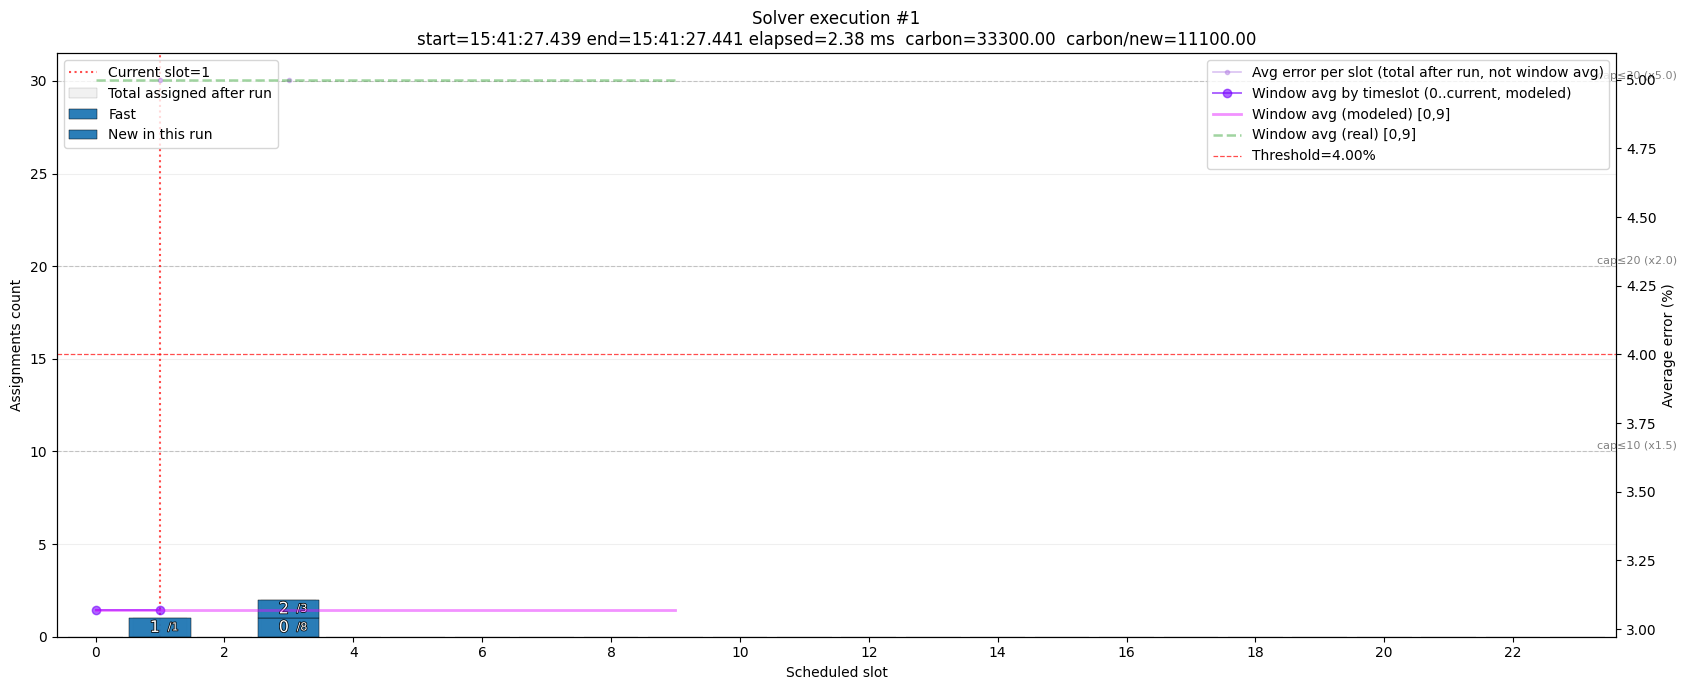

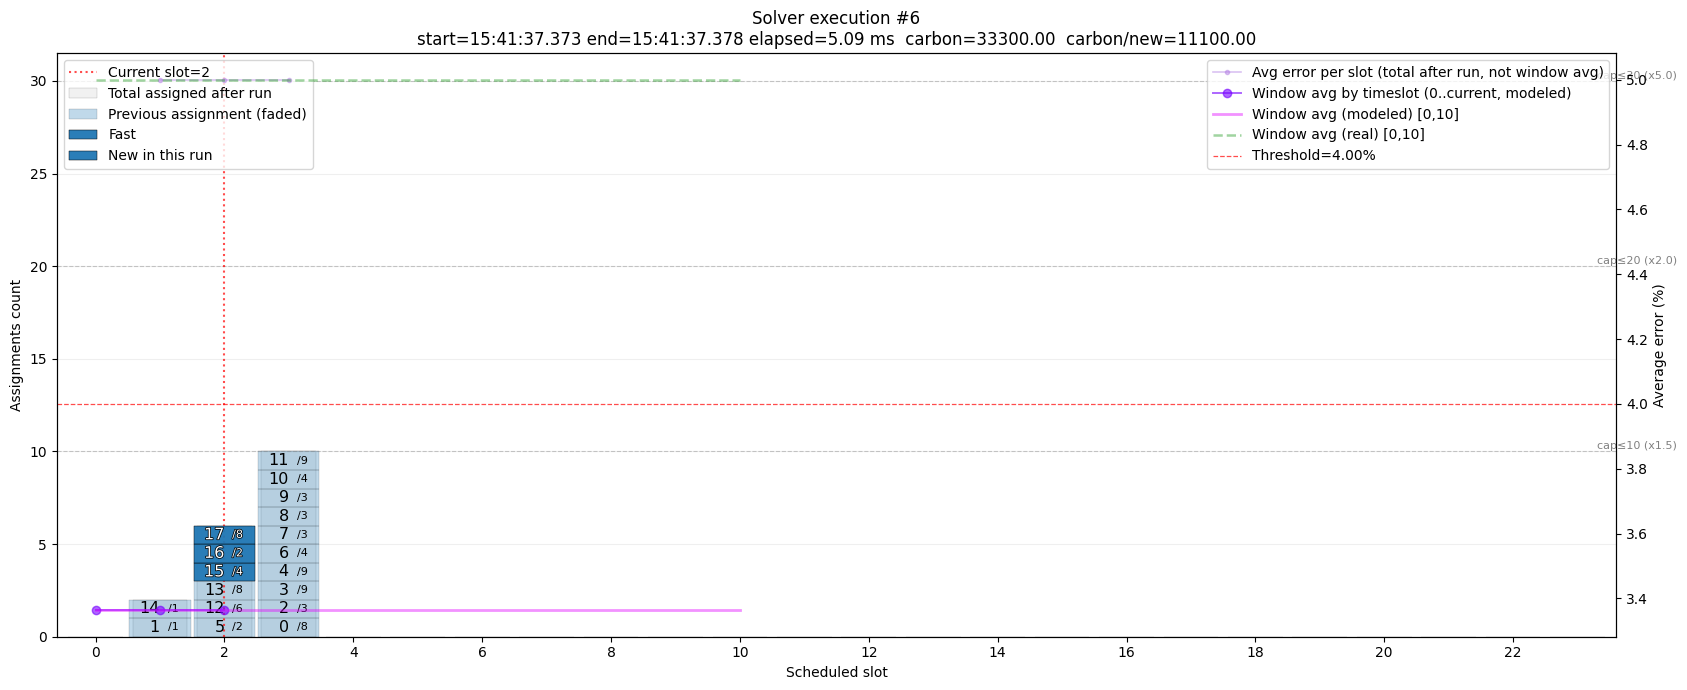

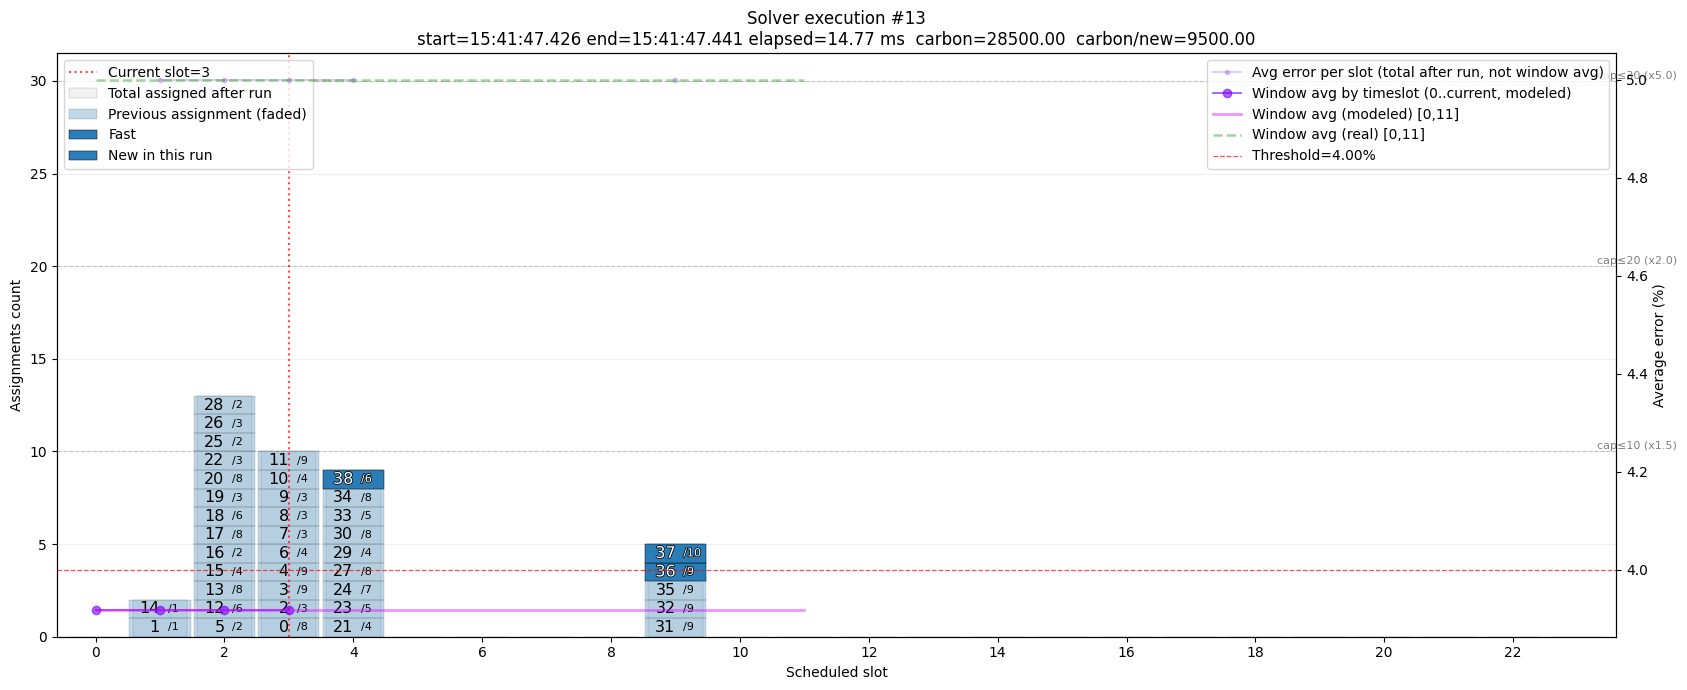

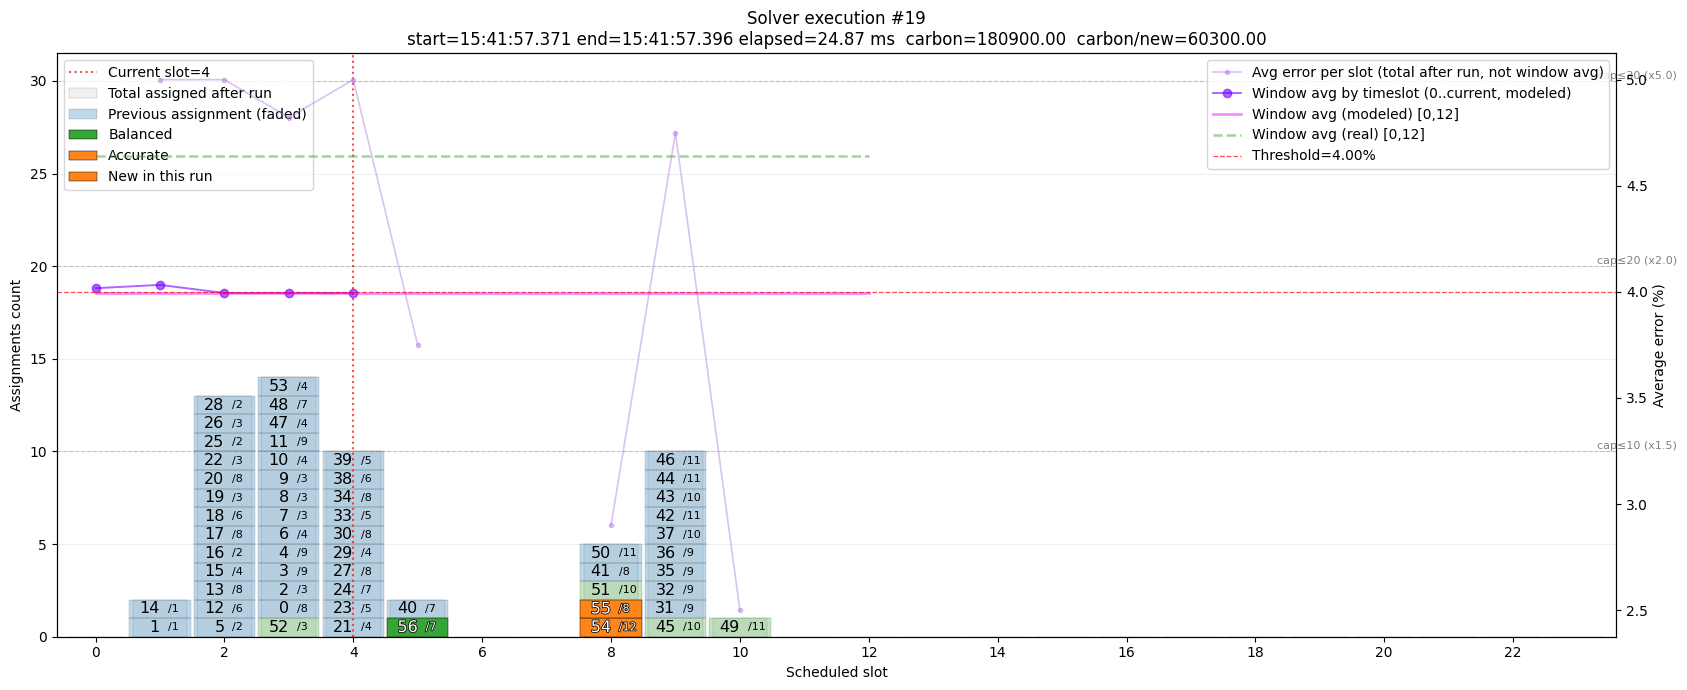

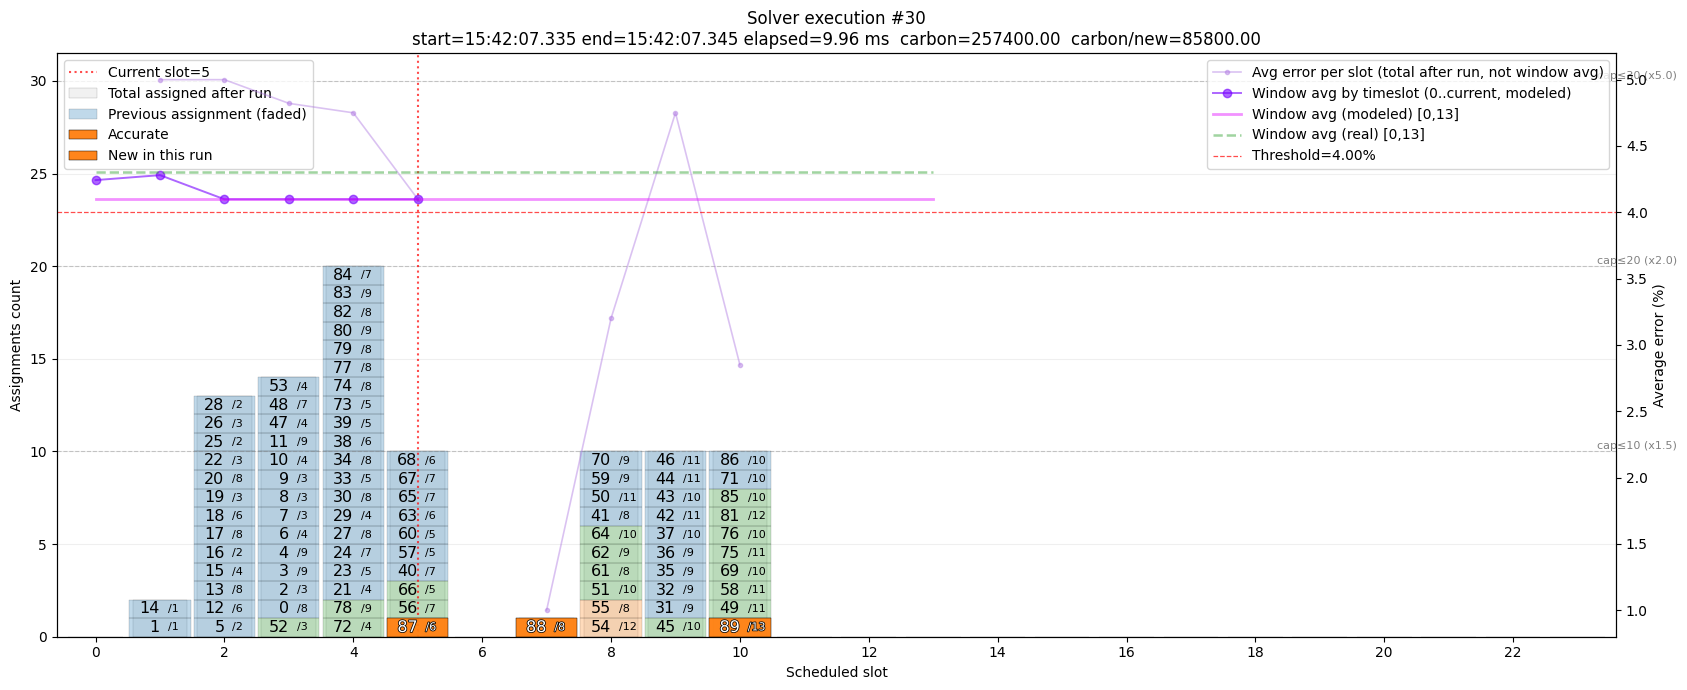

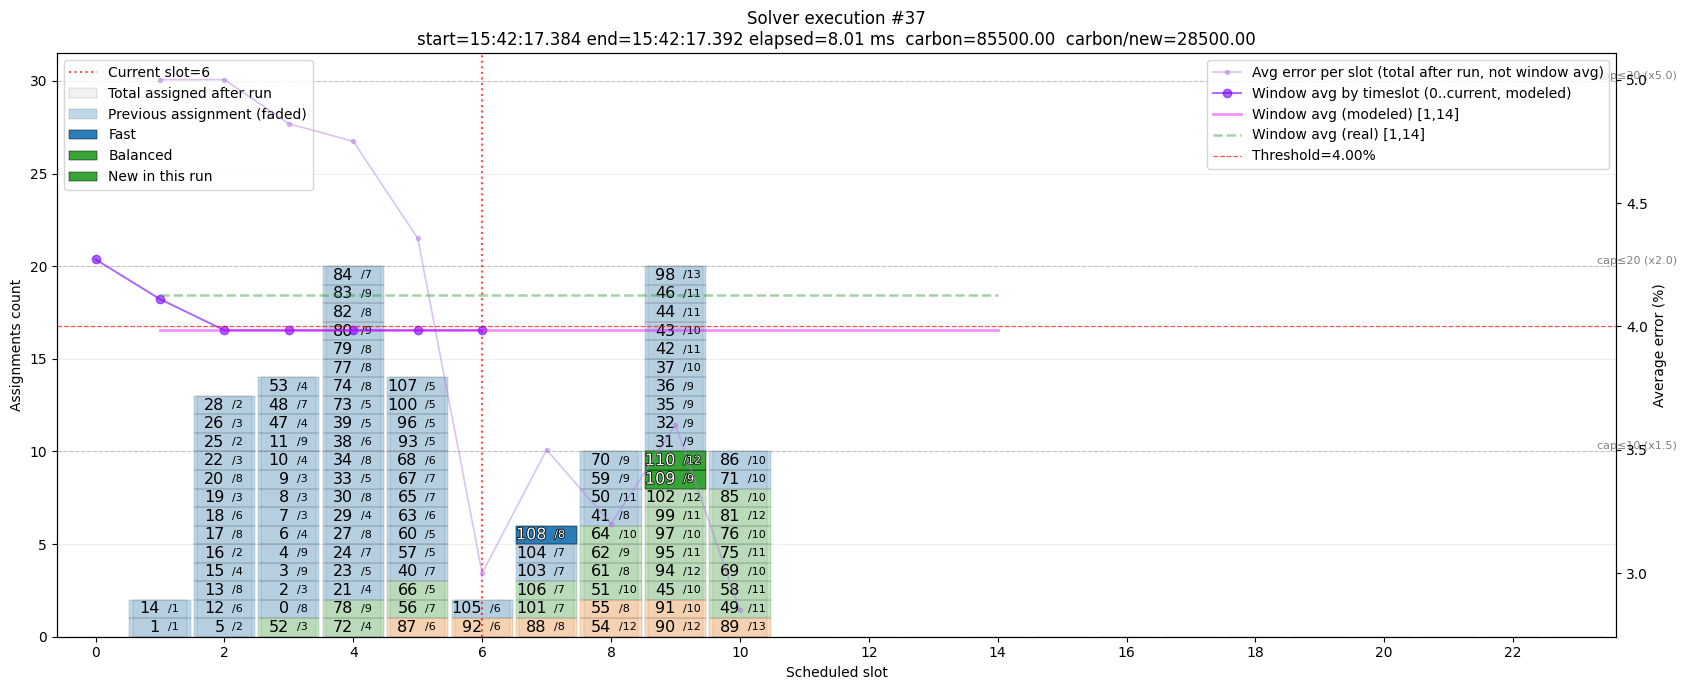

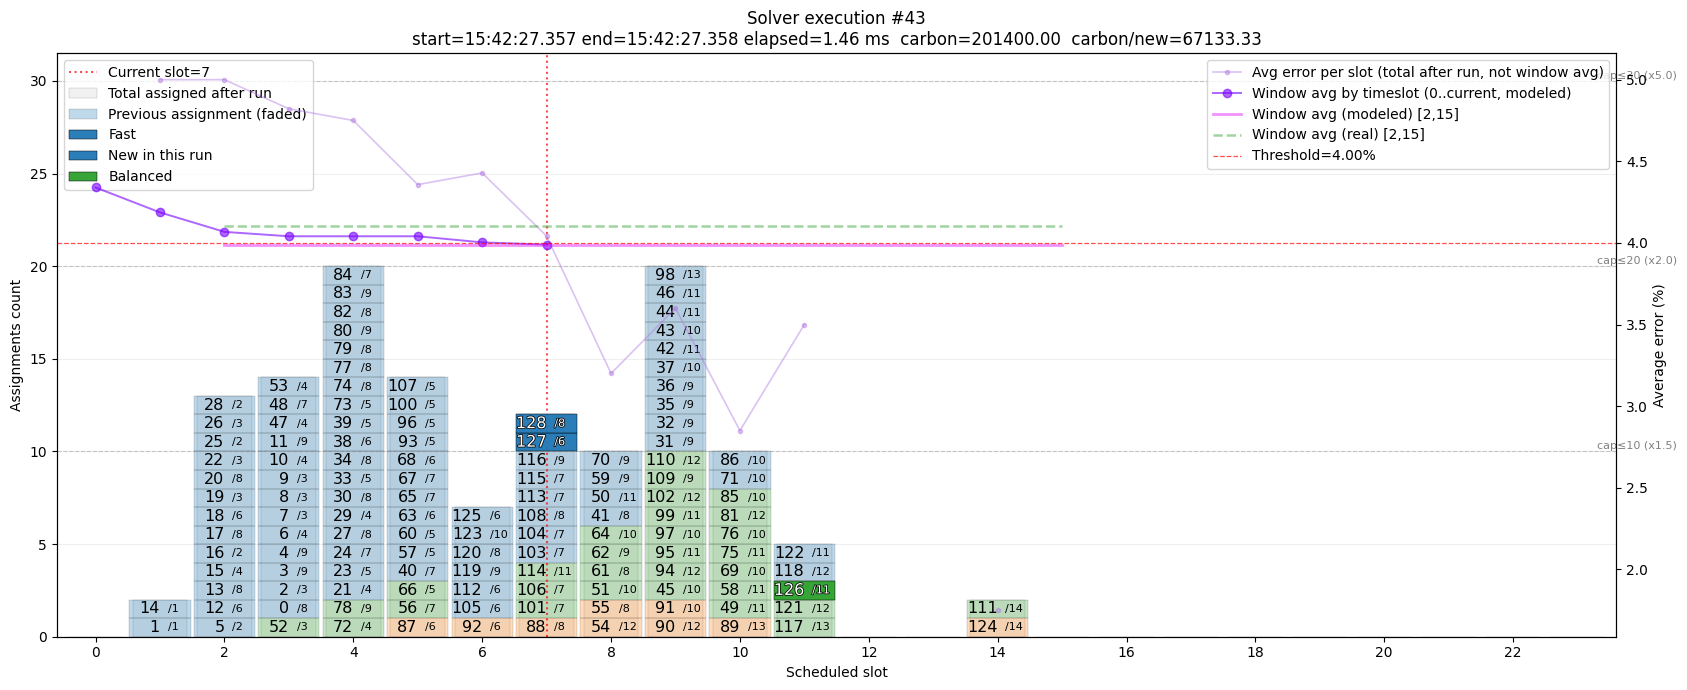

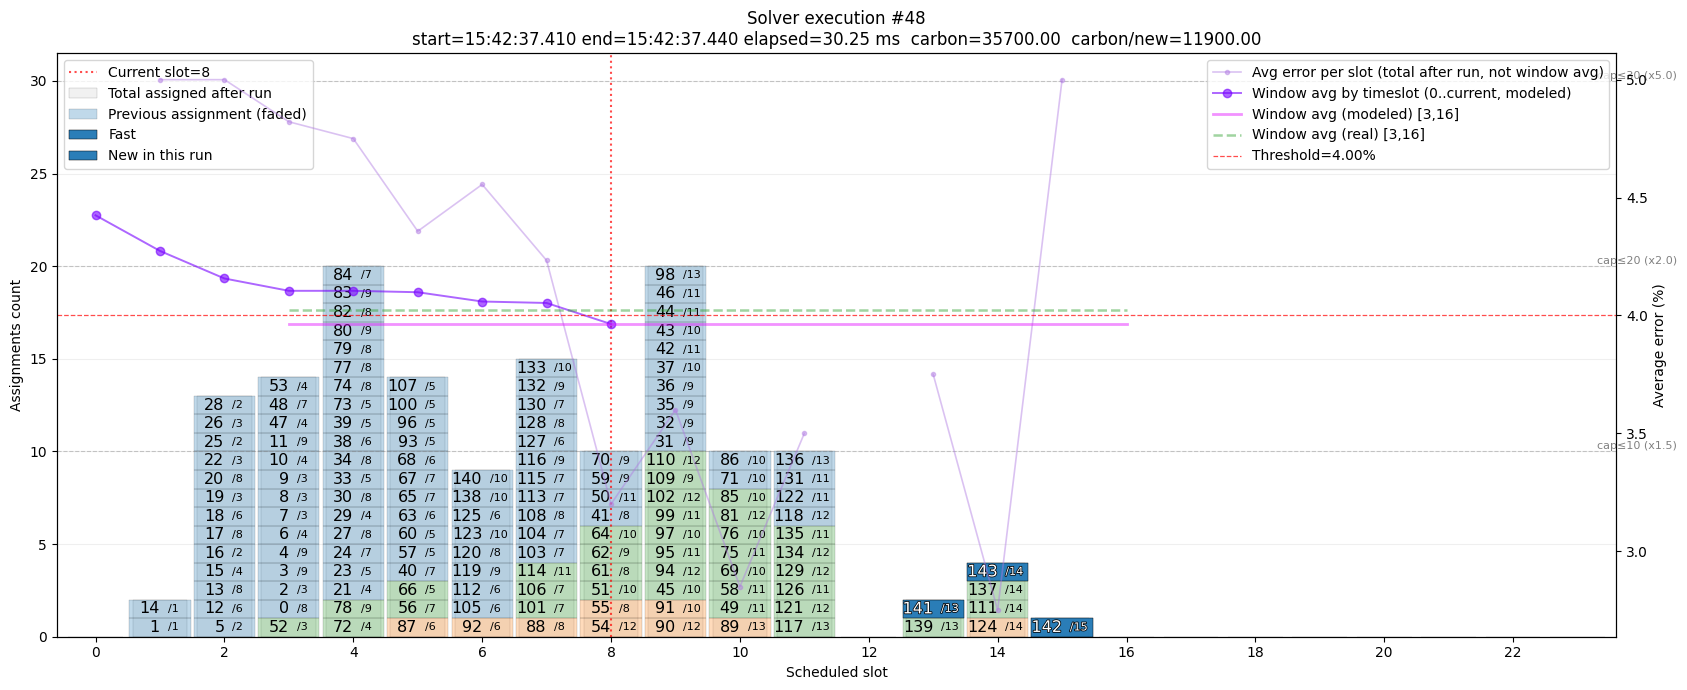

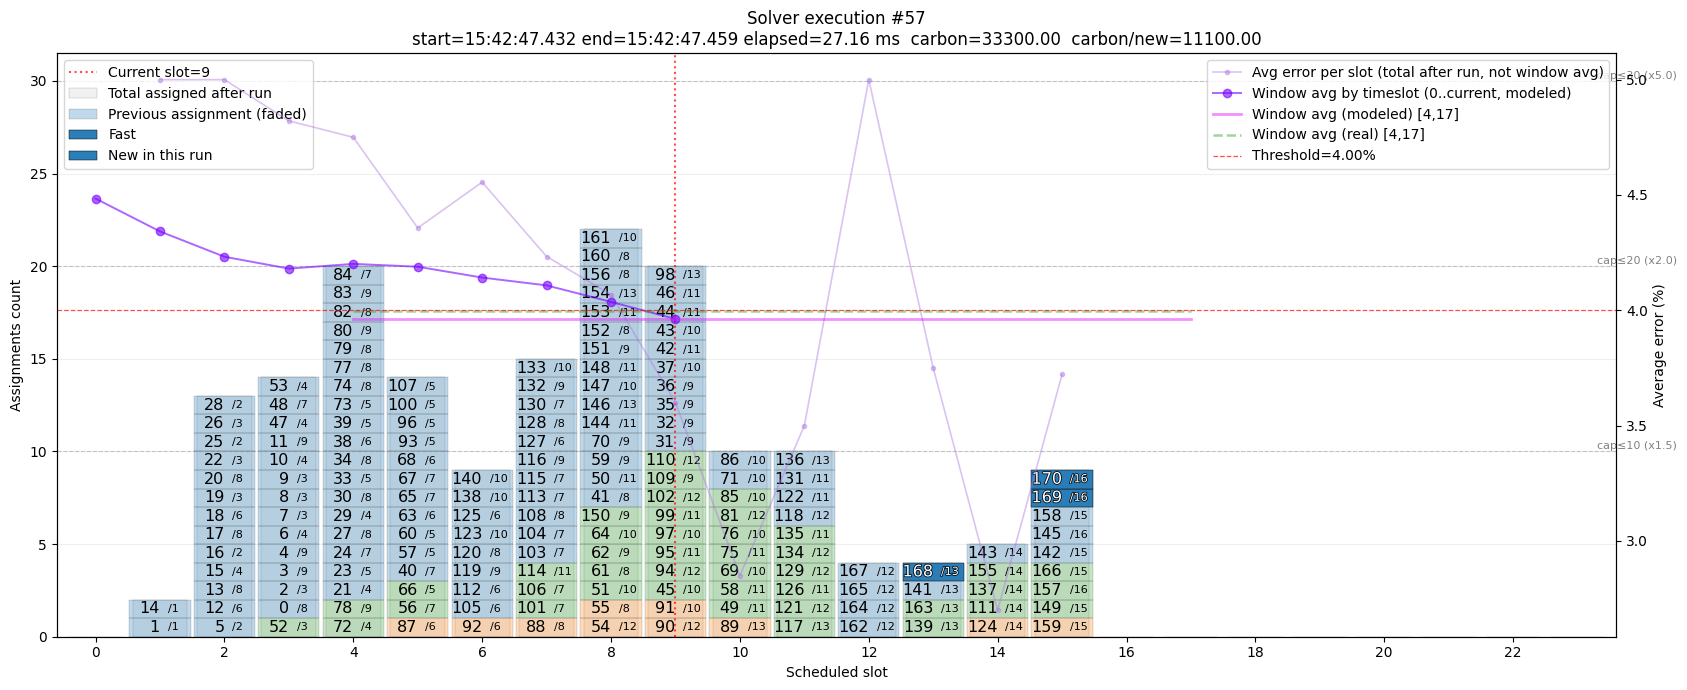

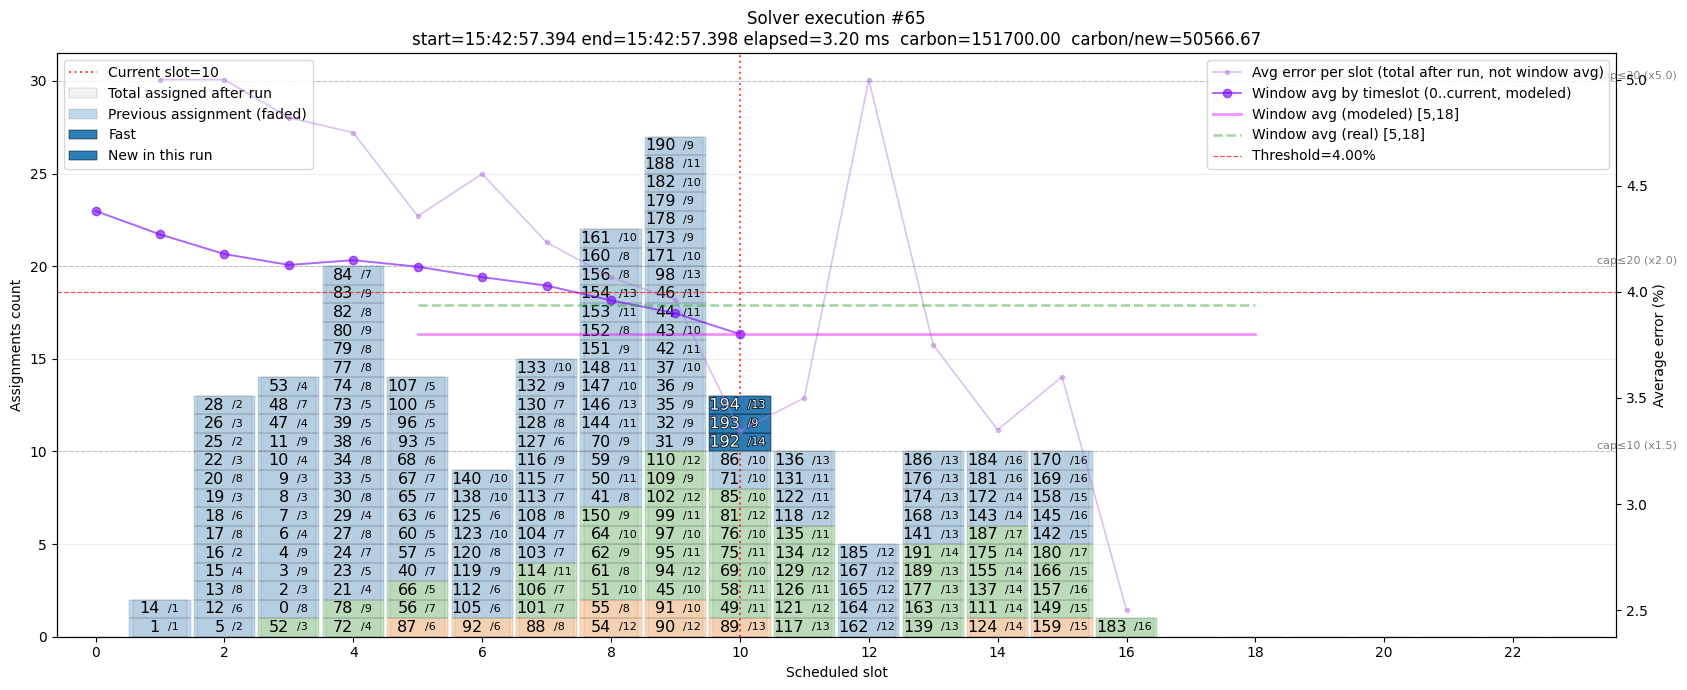

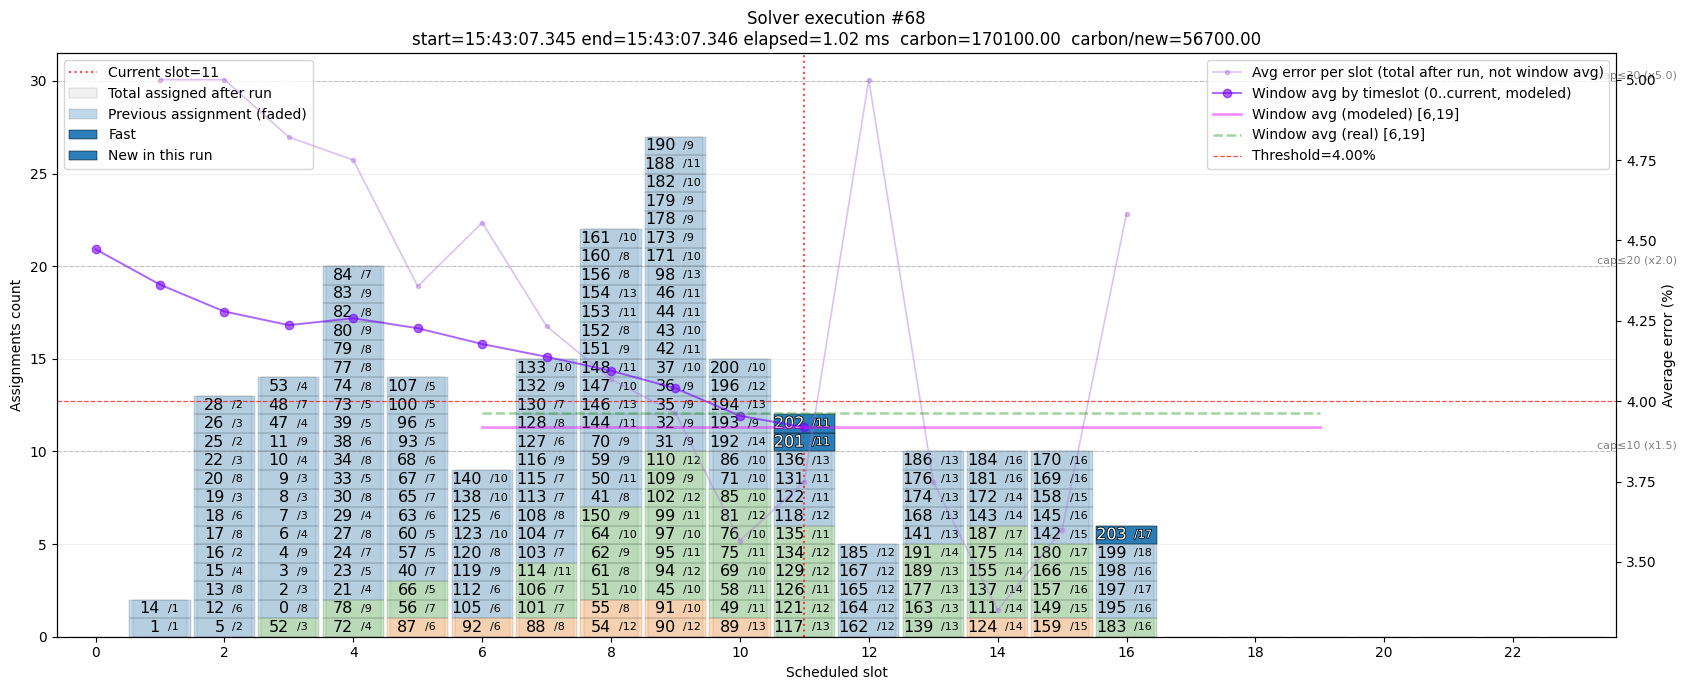

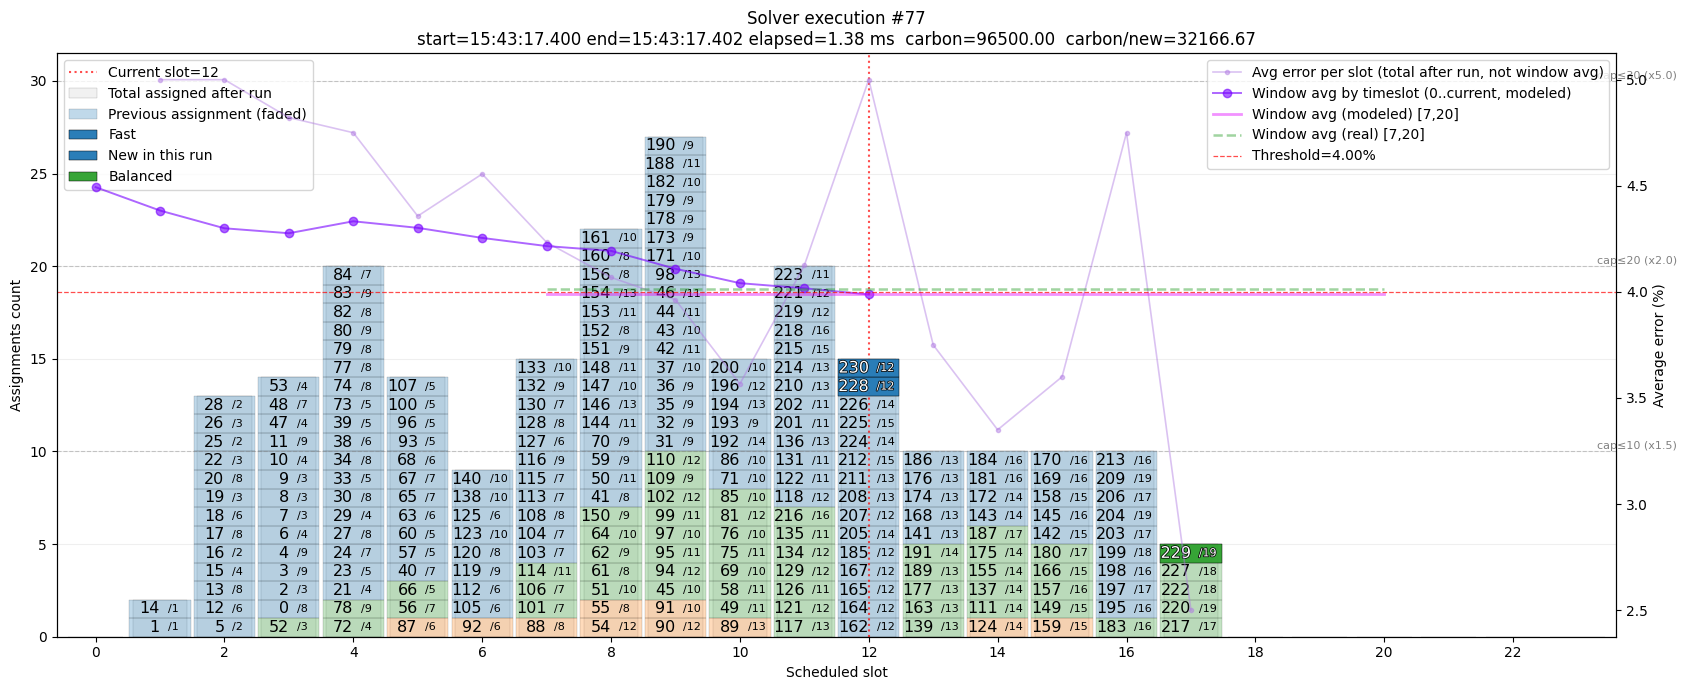

In [40]:
if runs_df.empty or assignments_df.empty:
    print("Dati insufficienti per i grafici stacked")
else:
    if not selected_run_ids:
        print("Nessun run selezionato con le opzioni correnti")
    for run_id in selected_run_ids:
        fig = plot_solver_execution_stacked(
            run_id=run_id,
            runs_df=runs_df,
            assignments_df=assignments_df,
            slot_metrics_df=slot_metrics_df,
        )
        plt.show()


## 3) Debug eventi di strict infeasibility

Questa sezione serve a capire quando il vincolo strict sulla finestra errore
non consente l'assegnamento completo e costringe al retry rilassato.


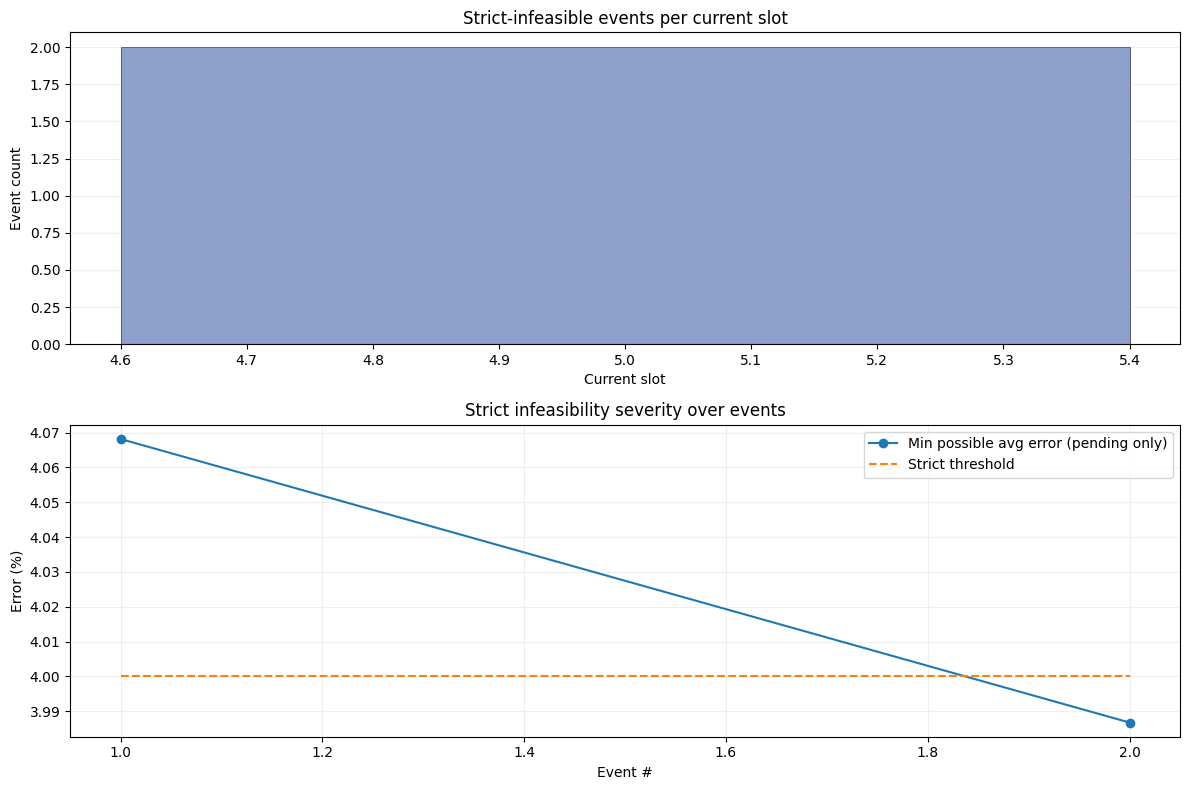

In [41]:
if debug_df.empty:
    print("Nessun evento strict-infeasible loggato")
else:
    fig = plot_infeasibility_overview(debug_df)
    plt.show()


,event_id,timestamp,current_slot,pending_batch_size,pending_request_details,strict_threshold,baseline_error_sum,baseline_request_count,baseline_average_error,min_strategy_error,...,max_possible_avg_error_pending_only,strict_infeasible_by_error_bound,strict_scheduled_pending_count,relaxed_scheduled_pending_count,relaxed_success,lock_future_assignments,future_assignment_count,future_slot_counts,future_assignment_details,all_active_slot_counts
1,1777470127460-5,1.777470e+09,5,3,92:6|91:10|90:12,4.0,447.5,110,4.068182,1.0,...,4.09292,False,0,3,True,True,41,5:10|7:1|8:10|9:10|10:10,40:5:7:Fast|56:5:7:Balanced|57:5:5:Fast|60:5:5...,1:2|2:13|3:14|4:20|5:10|7:1|8:10|9:10|10:10


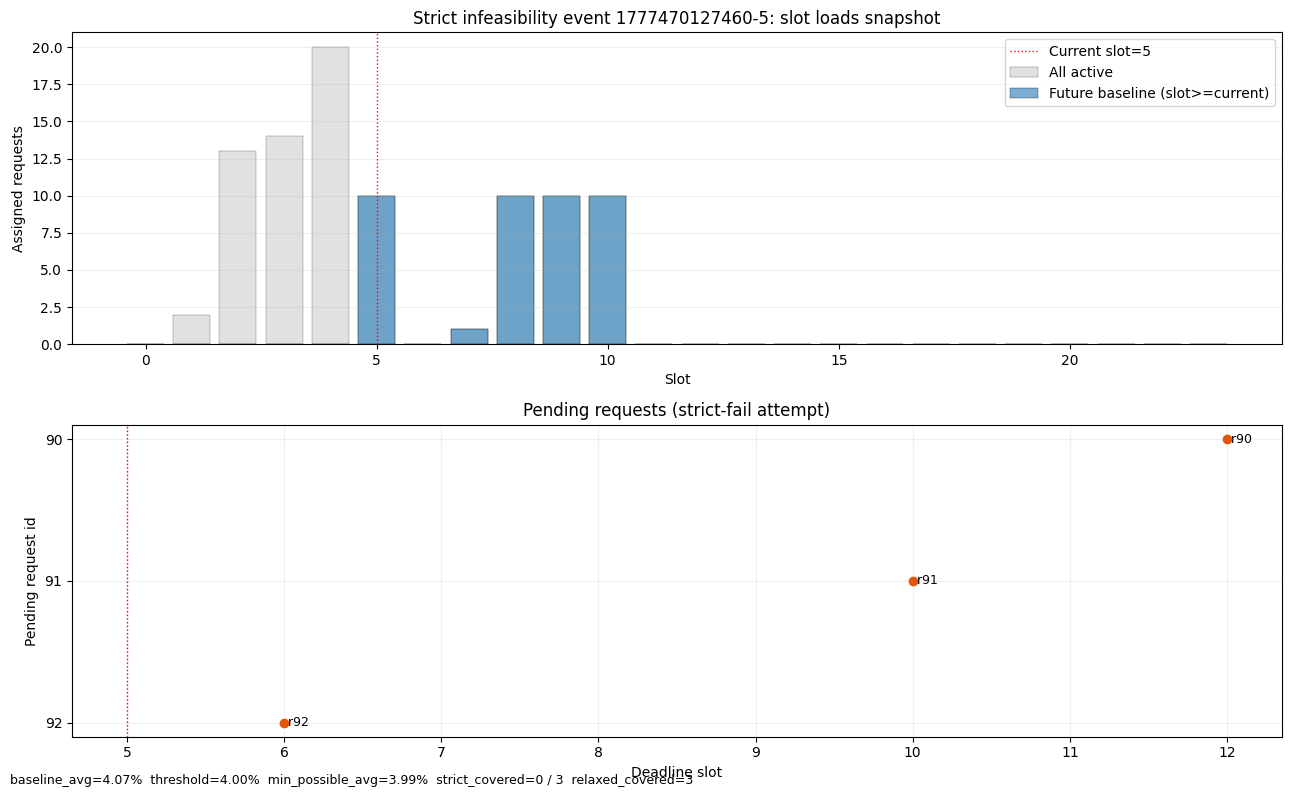

In [42]:
if debug_df.empty:
    print("Nessun evento strict-infeasible loggato")
else:
    selected_event_id = str(INFEASIBILITY_EVENT_ID) if INFEASIBILITY_EVENT_ID is not None else str(debug_df.iloc[-1]["event_id"])
    display(debug_df[debug_df["event_id"].astype(str) == selected_event_id])
    fig = plot_infeasibility_event(selected_event_id, debug_df)
    plt.show()


## Note

Se vuoi aggiornare i grafici, rilancia prima `python main.py --duration ...` e poi riesegui il notebook.

Per i primi slot, il solver può usare pre-history virtuale: per questo la media errore "modeled" e quella "real" possono differire.
